<a href="https://colab.research.google.com/github/CMS2123/EART60702/blob/main/Surface_Flux.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xarray netCDF4 pandas matplotlib seaborn cartopy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.7 MB/s eta 0:00:00


In [14]:
import xarray as xr

# File paths
historical_file = "hfls_Amon_HadGEM3-GC31-LL_historical_r1i1p1f3_gn_20060116-20141216.nc"
projected_file = "hfls_Amon_HadGEM3-GC31-LL_ssp245_r1i1p1f3_gn_20150116-20801216.nc"

# Open datasets
ds_hist = xr.open_dataset(historical_file, engine="netcdf4")
ds_proj = xr.open_dataset(projected_file, engine="netcdf4")

# Print structure
print(ds_hist)
print(ds_proj)



<xarray.Dataset> Size: 17kB
Dimensions:    (time: 108, bnds: 2, lat: 8, lon: 4)
Coordinates:
  * time       (time) object 864B 2006-01-16 00:00:00 ... 2014-12-16 00:00:00
  * lat        (lat) float64 64B 49.38 50.62 51.88 53.12 54.38 55.62 56.88 58.12
  * lon        (lon) float64 32B 353.4 355.3 357.2 359.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 2kB ...
    lat_bnds   (lat, bnds) float64 128B ...
    lon_bnds   (lon, bnds) float64 64B ...
    hfls       (time, lat, lon) float32 14kB ...
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    creation_date:          2019-06-19T12:05:32Z
    ...                     ...
    title:                  HadGEM3-GC31-LL output prepared for CMIP6
    variable_id:            hfls
    variant_label:          r1i1p1f3
    license:                CMIP6 model 

In [3]:
print(ds.variables.keys())


KeysView(Frozen({'time': <xarray.IndexVariable 'time' (time: 108)> Size: 864B
array([cftime.Datetime360Day(2006, 1, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2006, 2, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2006, 3, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2006, 4, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2006, 5, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2006, 6, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2006, 7, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2006, 8, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2006, 9, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2006, 10, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2006, 11, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2006, 12, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.Datet

In [15]:
import pandas as pd

# Convert to DataFrame
df_hist = ds_hist["hfls"].to_dataframe().reset_index()
df_proj = ds_proj["hfls"].to_dataframe().reset_index()

# Convert time to datetime
df_hist["time"] = pd.to_datetime(df_hist["time"].astype(str))
df_proj["time"] = pd.to_datetime(df_proj["time"].astype(str))

# Set index
df_hist.set_index("time", inplace=True)
df_proj.set_index("time", inplace=True)

# Merge datasets
df_combined = pd.concat([df_hist, df_proj])

# Display
print(df_combined.head())


               lat       lon        hfls
time                                    
2006-01-16  49.375  353.4375  101.983398
2006-01-16  49.375  355.3125   85.511169
2006-01-16  49.375  357.1875   53.802368
2006-01-16  49.375  359.0625   34.601685
2006-01-16  50.625  353.4375   87.245483


In [5]:
df_hist.dropna(inplace=True)  # Remove NaN values
df_proj.dropna(inplace=True)

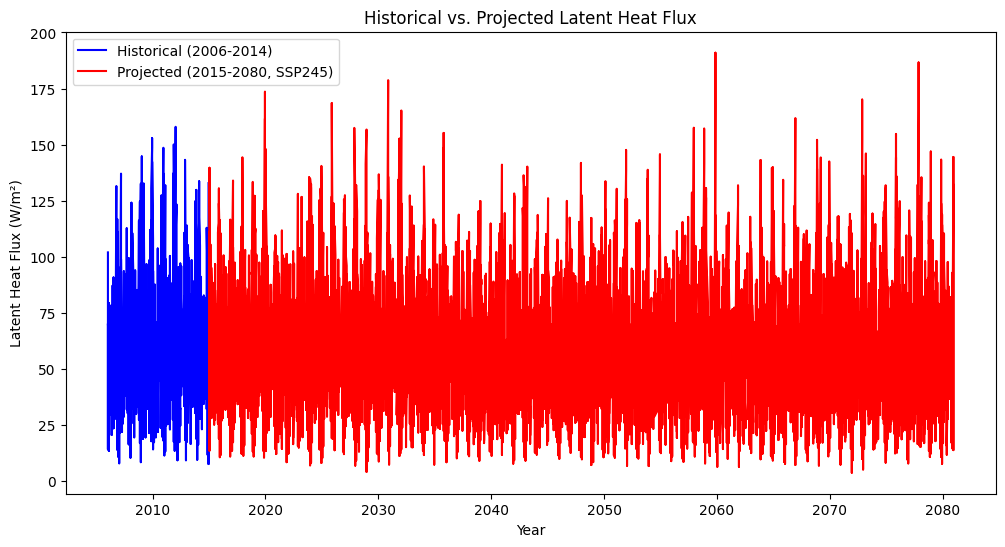

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot historical & projected data
plt.plot(df_hist.index, df_hist["hfls"], label="Historical (2006-2014)", color="blue")
plt.plot(df_proj.index, df_proj["hfls"], label="Projected (2015-2080, SSP245)", color="red")

plt.xlabel("Year")
plt.ylabel("Latent Heat Flux (W/m²)")
plt.title("Historical vs. Projected Latent Heat Flux")
plt.legend()
plt.show()


In [18]:
from scipy.stats import linregress

# Historical trend
slope_hist, _, _, p_hist, _ = linregress(df_hist.index.year, df_hist["hfls"])
print(f"Historical Trend: {slope_hist:.4f} W/m² per year (p={p_hist:.4f})")

# Projected trend
slope_proj, _, _, p_proj, _ = linregress(df_proj.index.year, df_proj["hfls"])
print(f"Projected Trend: {slope_proj:.4f} W/m² per year (p={p_proj:.4f})")


Historical Trend: 0.2560 W/m² per year (p=0.0967)
Projected Trend: -0.0157 W/m² per year (p=0.0348)


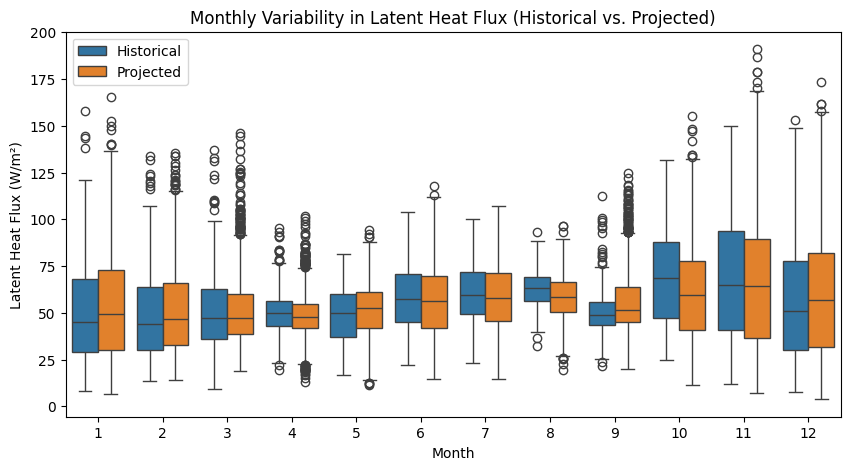

In [19]:
import seaborn as sns

df_combined["month"] = df_combined.index.month  # Extract month
df_combined["period"] = ["Historical" if year < 2015 else "Projected" for year in df_combined.index.year]

plt.figure(figsize=(10,5))
sns.boxplot(x="month", y="hfls", hue="period", data=df_combined)
plt.title("Monthly Variability in Latent Heat Flux (Historical vs. Projected)")
plt.xlabel("Month")
plt.ylabel("Latent Heat Flux (W/m²)")
plt.legend()
plt.show()


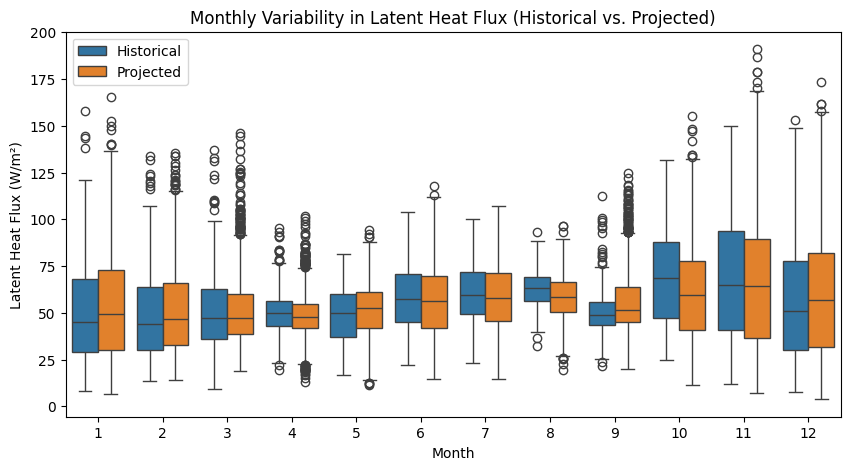

In [20]:
import seaborn as sns

df_combined["month"] = df_combined.index.month  # Extract month
df_combined["period"] = ["Historical" if year < 2015 else "Projected" for year in df_combined.index.year]

plt.figure(figsize=(10,5))
sns.boxplot(x="month", y="hfls", hue="period", data=df_combined)
plt.title("Monthly Variability in Latent Heat Flux (Historical vs. Projected)")
plt.xlabel("Month")
plt.ylabel("Latent Heat Flux (W/m²)")
plt.legend()
plt.show()


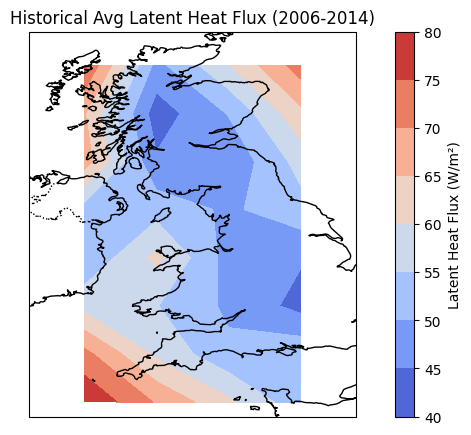

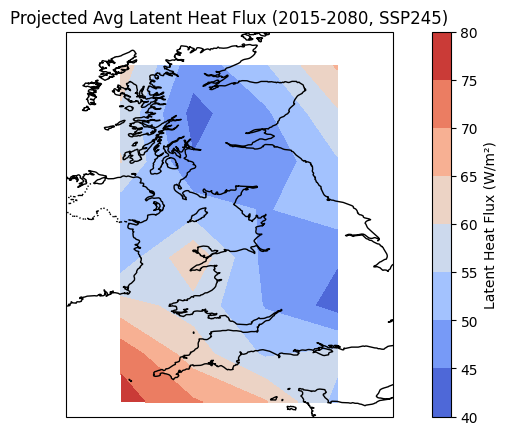

In [21]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Compute mean latent heat flux for both periods
hfls_mean_hist = ds_hist["hfls"].mean(dim="time")
hfls_mean_proj = ds_proj["hfls"].mean(dim="time")

# Extract lat, lon, and data
lons = ds_hist["lon"]
lats = ds_hist["lat"]

# Plot Historical Data
plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-8, 0.5, 49, 59], crs=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_title("Historical Avg Latent Heat Flux (2006-2014)")
plt.contourf(lons, lats, hfls_mean_hist, transform=ccrs.PlateCarree(), cmap="coolwarm")
plt.colorbar(label="Latent Heat Flux (W/m²)")
plt.show()

# Plot Projected Data
plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-8, 0.5, 49, 59], crs=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_title("Projected Avg Latent Heat Flux (2015-2080, SSP245)")
plt.contourf(lons, lats, hfls_mean_proj, transform=ccrs.PlateCarree(), cmap="coolwarm")
plt.colorbar(label="Latent Heat Flux (W/m²)")
plt.show()


In [7]:
csv_path = "processed_latent_heat_flux.csv"
df.to_csv(csv_path)
print(f"Saved processed data to {csv_path}")


Saved processed data to processed_latent_heat_flux.csv


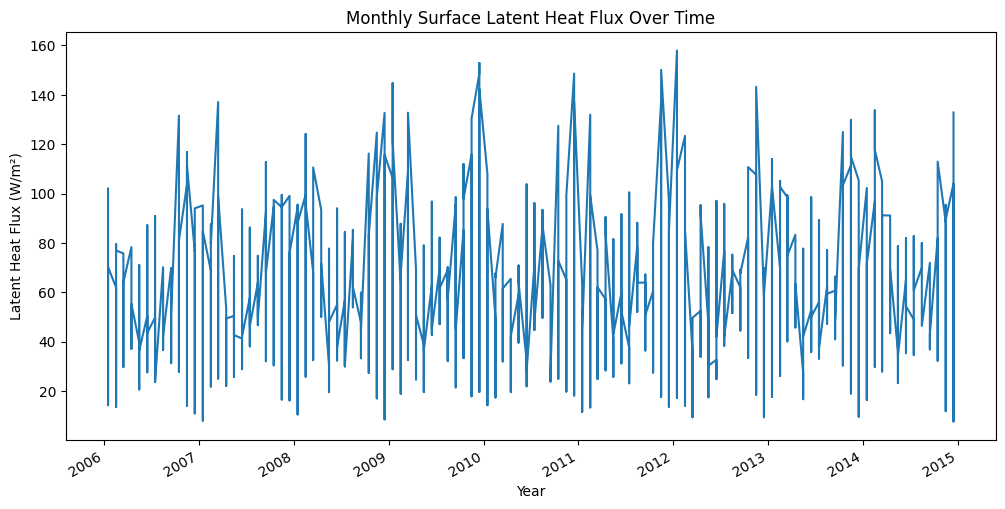

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df["hfls"].plot(title="Monthly Surface Latent Heat Flux Over Time")
plt.xlabel("Year")
plt.ylabel("Latent Heat Flux (W/m²)")
plt.show()


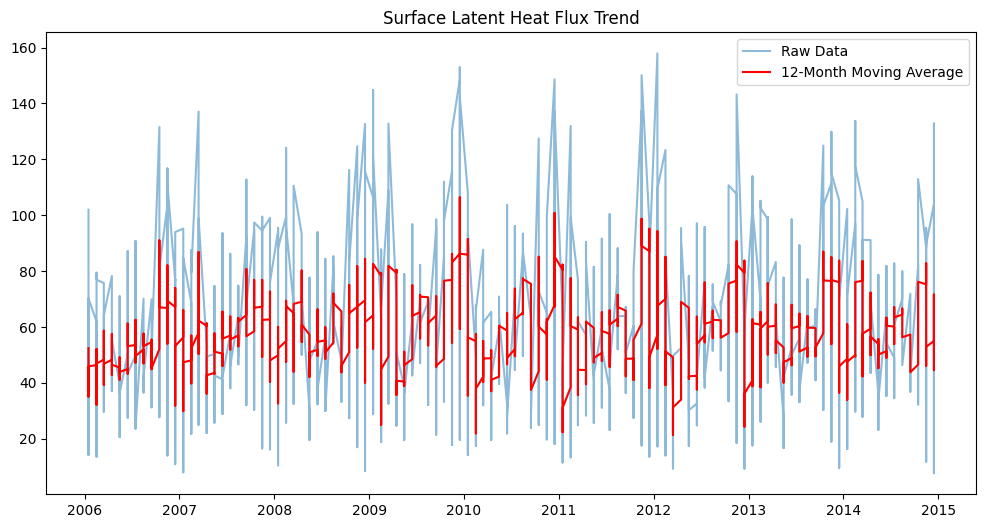

In [9]:
df["hfls_MA"] = df["hfls"].rolling(window=12).mean()  # 12-month moving avg

plt.figure(figsize=(12,6))
plt.plot(df.index, df["hfls"], alpha=0.5, label="Raw Data")
plt.plot(df.index, df["hfls_MA"], color="red", label="12-Month Moving Average")
plt.title("Surface Latent Heat Flux Trend")
plt.legend()
plt.show()


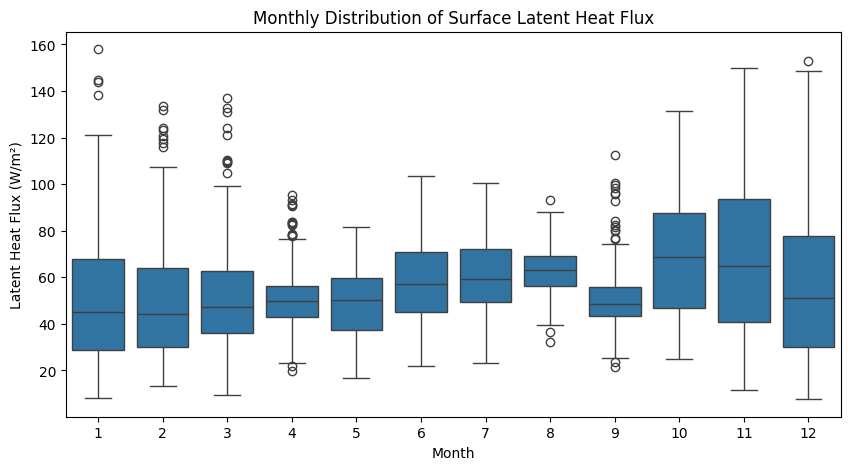

In [10]:
import seaborn as sns

df["month"] = df.index.month  # Extract month for seasonal analysis
plt.figure(figsize=(10,5))
sns.boxplot(x="month", y="hfls", data=df)
plt.title("Monthly Distribution of Surface Latent Heat Flux")
plt.xlabel("Month")
plt.ylabel("Latent Heat Flux (W/m²)")
plt.show()


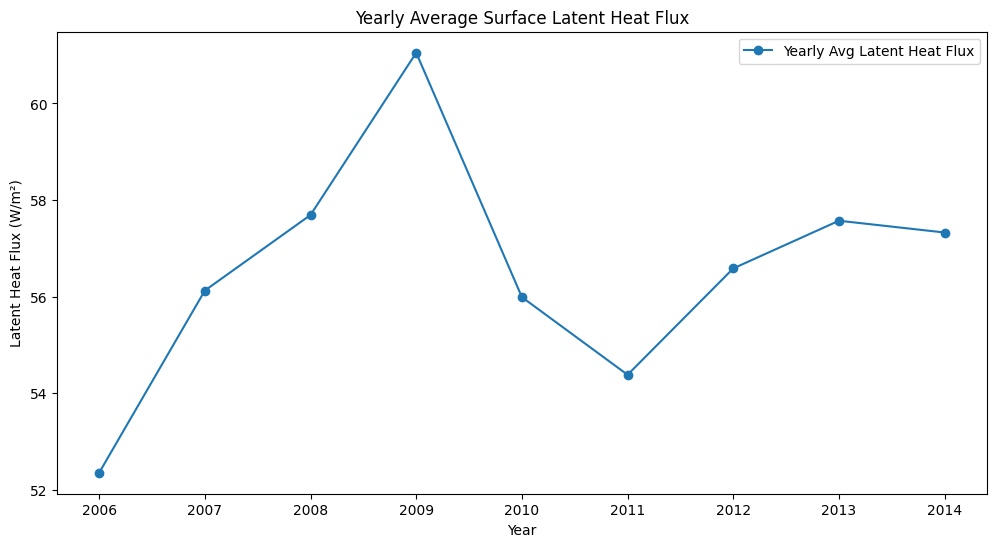

In [11]:
df["year"] = df.index.year
yearly_avg = df.groupby("year")["hfls"].mean()

plt.figure(figsize=(12,6))
plt.plot(yearly_avg, marker="o", linestyle="-", label="Yearly Avg Latent Heat Flux")
plt.xlabel("Year")
plt.ylabel("Latent Heat Flux (W/m²)")
plt.title("Yearly Average Surface Latent Heat Flux")
plt.legend()
plt.show()


In [12]:
correlation = df["hfls"].corr(pd.Series(df.index.year, index=df.index))
print(f"Correlation between time and surface latent heat flux: {correlation:.4f}")


Correlation between time and surface latent heat flux: 0.0283


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


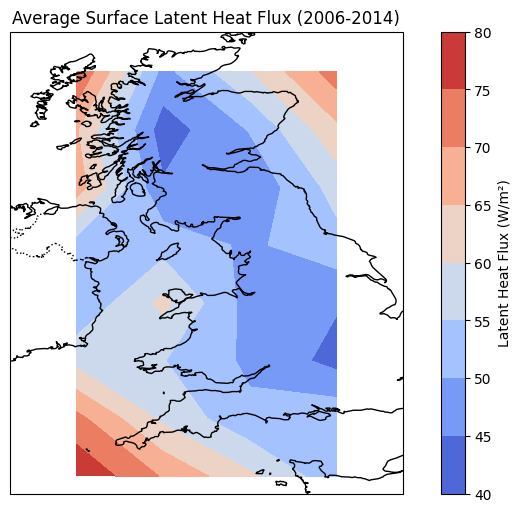

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Compute mean latent heat flux over the entire time period
hfls_mean = ds["hfls"].mean(dim="time")

# Extract lat, lon, and data
lons = ds["lon"]
lats = ds["lat"]
data = hfls_mean

plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-8, 0.5, 49, 59], crs=ccrs.PlateCarree())  # UK region
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_title("Average Surface Latent Heat Flux (2006-2014)")

# Plot data
plt.contourf(lons, lats, data, transform=ccrs.PlateCarree(), cmap="coolwarm")

# Show the plot
plt.colorbar(label="Latent Heat Flux (W/m²)")
plt.show()
